# 41 — New Jersey sportsbook GGR data-quality walkthrough (revised)

## Purpose, scope, and non-goals

New Jersey online sportsbook GGR is currently **unsafe for comparable multi-state analysis**. This notebook diagnoses **two separate parser defects** without mutating production code, the database, or retained PDFs:

| Defect | Layout | Mechanism |
| --- | --- | --- |
| **A. Skin cross-column concatenation** | sports-skin tables | `repair_pdf_line` on a flattened row joins adjacent split numbers |
| **B. Tax-page dash → line-number leakage** | sports-tax forms | `_first_amount` falls back to whole-line tokens when the value cell is a dash, capturing form line numbers (and sometimes the `13` in `13%`) |

Missing **handle** is expected from the official DGE reports and is **not** treated as a parser defect.

**Non-goals:** no edits to `new_jersey.py`, tests, fixtures, SQLite, CSVs, or raw PDFs; a successful prototype is **not** production approval.

### Central questions

1. Can corrupt SQLite values be reproduced from retained PDFs?
2. Where do defects A and B occur in the extraction pipeline?
3. Can cell boundaries eliminate both classes of error?
4. Do layout-specific prototypes cover all 98 retained sportsbook reports?
5. Which edge cases remain unresolved?


## 1. Imports and immutable setup

**What:** Resolve paths, hash SQLite, open `mode=ro`, prove writes fail.

**Why:** All claims depend on an untampered snapshot and local PDFs only.

**Inspect:** paths, SHA-256, write rejection.

**Failure:** wrong repo, writable DB, or missing NJ raw root.


In [1]:
from __future__ import annotations

import hashlib
import re
import sqlite3
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber

from variant_gaming.common import project_root
from variant_gaming.storage import RESULT_COLUMNS, default_db_path
from variant_gaming.states.new_jersey import (
    SPORTS_GGR_LABELS,
    SPORTS_SKIN_GGR_LABELS,
    SPORTS_TAX_LABELS,
    SPORTS_VERTICAL,
    _cell_text,
    _classify_nj_page,
    _first_amount,
    _page_period,
    money_tokens,
    parse_nj_pdf,
    parse_sports_tax_page,
    repair_pdf_line,
)

warnings.filterwarnings("ignore", category=UserWarning, module="pdfplumber")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option(
    "display.float_format",
    lambda v: f"{v:,.2f}" if pd.notna(v) and abs(v) < 1e12 else (f"{v:.6e}" if pd.notna(v) else ""),
)

ROOT = project_root()
assert ROOT.resolve() == Path(r"C:\Users\Sean\VscProjects\researchOS").resolve(), ROOT
DATABASE_PATH = default_db_path(ROOT)
NJ_RAW_ROOT = (ROOT / "data" / "raw" / "NJ").resolve()
assert DATABASE_PATH.is_file() and NJ_RAW_ROOT.is_dir()

DATABASE_SHA256_BEFORE = hashlib.sha256(DATABASE_PATH.read_bytes()).hexdigest()
print("ROOT", ROOT)
print("DATABASE_PATH", DATABASE_PATH)
print("DATABASE_SHA256_BEFORE", DATABASE_SHA256_BEFORE)

connection = sqlite3.connect(f"file:{DATABASE_PATH.as_posix()}?mode=ro", uri=True)
connection.row_factory = sqlite3.Row
write_rejected = False
try:
    connection.execute("CREATE TABLE __readonly_probe(x INTEGER)")
except sqlite3.OperationalError as exc:
    write_rejected = True
    print("write_rejected:", type(exc).__name__, str(exc))
assert write_rejected
print("read_only_confirmed", True)


ROOT C:\Users\Sean\VscProjects\researchOS
DATABASE_PATH C:\Users\Sean\VscProjects\researchOS\data\gaming.sqlite
DATABASE_SHA256_BEFORE fb3bc37e92ba12f5ad08fc55aeb0968ba7dec207e60dd887beee2be4a5ce87c6
write_rejected: OperationalError attempt to write a readonly database
read_only_confirmed True


## 2. Raw NJ sportsbook inspection

**What:** Profile all `NJ` / `online_sports_betting` rows.

**Why:** Separate expected null handle from corrupt GGR magnitudes and establish period/retrieval clocks.

**Inspect:** shape, dtypes, samples, missingness, duplicates, identifier distributions.

**Failure:** empty frame or unparseable timestamps.


In [2]:
nj = pd.read_sql_query(
    """
    SELECT * FROM gaming_results
    WHERE state_code = 'NJ' AND vertical = 'online_sports_betting'
    ORDER BY period_start, operator, source_sha256
    """,
    connection,
)
assert not nj.empty
assert set(RESULT_COLUMNS).issubset(nj.columns)

nj["period_start_dt"] = pd.to_datetime(nj["period_start"], utc=True)
nj["period_end_dt"] = pd.to_datetime(nj["period_end"], utc=True)
nj["retrieved_at_dt"] = pd.to_datetime(nj["retrieved_at_utc"], utc=True)
assert nj[["period_start_dt", "period_end_dt", "retrieved_at_dt"]].notna().all().all()
assert getattr(nj["retrieved_at_dt"].dtype, "tz", None) is not None
assert str(nj["retrieved_at_dt"].dtype.tz) == "UTC"

print("shape", nj.shape)
print("period_min_max", nj["period_start"].min(), nj["period_start"].max())
print("retrieved_min_max", nj["retrieved_at_utc"].min(), nj["retrieved_at_utc"].max())
print("n_operators", nj["operator"].nunique(), "n_sources", nj["source_sha256"].nunique())
display(nj.dtypes.to_frame("dtype"))
display(nj.head(4))
display(nj.tail(4))
display(nj.sample(4, random_state=41))

missing = pd.DataFrame({"null_count": nj.isna().sum(), "null_pct": (100 * nj.isna().mean()).round(2)})
display(missing)
print("exact_dupes", int(nj.duplicated().sum()))
biz = ["state_code", "vertical", "channel", "operator", "row_type", "period_start", "period_end"]
print("logical_biz_dupes", int(nj.duplicated(biz).sum()))
print("pk_with_hash_dupes", int(nj.duplicated(biz + ["source_sha256"]).sum()))
for col in ["row_type", "channel", "frequency", "reported_revenue_name", "report_status"]:
    display(nj[col].value_counts(dropna=False).to_frame(col))
display(nj.groupby(nj["period_start_dt"].dt.year).size().rename("rows").to_frame())


shape (1234, 24)
period_min_max 2018-06-01 2026-07-01
retrieved_min_max 2026-09-03T01:45:37.659759+00:00 2026-09-03T01:45:37.659759+00:00
n_operators 81 n_sources 98


,dtype
jurisdiction,str
state_code,str
vertical,str
channel,str
operator,str
row_type,str
period_start,str
period_end,str
frequency,str
handle,object


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status,period_start_dt,period_end_dt,retrieved_at_dt
0,New Jersey,NJ,online_sports_betting,online,BORGATA HOTEL CASINO & SPA,operator,2018-06-01,2018-06-30,monthly,None,8.00,None,0.00,None,14.00,Current Month Internet Sports Wagering Gross R...,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/b458b31a59d903a61077018...,b458b31a59d903a61077018d9ae666c7a3a245b7b96f6f...,2026-09-03T01:45:37.659759+00:00,ok,2018-06-01 00:00:00+00:00,2018-06-30 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
1,New Jersey,NJ,online_sports_betting,online,DARBY DEVELOPMENT / WILLIAM HILL,operator,2018-06-01,2018-06-30,monthly,None,8.00,None,0.00,None,14.00,Current Month Internet Sports Wagering Gross R...,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/b458b31a59d903a61077018...,b458b31a59d903a61077018d9ae666c7a3a245b7b96f6f...,2026-09-03T01:45:37.659759+00:00,ok,2018-06-01 00:00:00+00:00,2018-06-30 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
2,New Jersey,NJ,online_sports_betting,online,OCEAN RESORT CASINO,operator,2018-06-01,2018-06-30,monthly,None,8.00,None,0.00,None,14.00,Current Month Internet Sports Wagering Gross R...,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/b458b31a59d903a61077018...,b458b31a59d903a61077018d9ae666c7a3a245b7b96f6f...,2026-09-03T01:45:37.659759+00:00,ok,2018-06-01 00:00:00+00:00,2018-06-30 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
3,New Jersey,NJ,online_sports_betting,online,BORGATA HOTEL CASINO & SPA,operator,2018-07-01,2018-07-31,monthly,None,8.00,None,0.00,None,14.00,Current Month Internet Sports Wagering Gross R...,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/bbf66fbca5f77028c3a2873...,bbf66fbca5f77028c3a287374e4c2a7b1d5cf3eebd38f9...,2026-09-03T01:45:37.659759+00:00,ok,2018-07-01 00:00:00+00:00,2018-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status,period_start_dt,period_end_dt,retrieved_at_dt
1230,New Jersey,NJ,online_sports_betting,online,Fanduel,operator,2026-07-01,2026-07-31,monthly,None,"32,843,751.00",None,0.00,None,0.00,Monthly Online Sportsbook Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/0ad99b946e4cde9687a50e6...,0ad99b946e4cde9687a50e6294db1908503ed96bdbb62f...,2026-09-03T01:45:37.659759+00:00,ok,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
1231,New Jersey,NJ,online_sports_betting,online,HARD ROCK BET,operator,2026-07-01,2026-07-31,monthly,None,2.601171e+13,None,0.00,None,0.00,Monthly Online Sportsbook Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/0ad99b946e4cde9687a50e6...,0ad99b946e4cde9687a50e6294db1908503ed96bdbb62f...,2026-09-03T01:45:37.659759+00:00,ok,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
1232,New Jersey,NJ,online_sports_betting,online,Prime,operator,2026-07-01,2026-07-31,monthly,None,"293,511.00",None,0.00,None,0.00,Monthly Online Sportsbook Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/0ad99b946e4cde9687a50e6...,0ad99b946e4cde9687a50e6294db1908503ed96bdbb62f...,2026-09-03T01:45:37.659759+00:00,ok,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
1233,New Jersey,NJ,online_sports_betting,online,betParx,operator,2026-07-01,2026-07-31,monthly,None,"147,683.00",None,0.00,None,0.00,Monthly Online Sportsbook Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/0ad99b946e4cde9687a50e6...,0ad99b946e4cde9687a50e6294db1908503ed96bdbb62f...,2026-09-03T01:45:37.659759+00:00,ok,2026-07-01 00:00:00+00:00,2026-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00


,jurisdiction,state_code,vertical,channel,operator,row_type,period_start,period_end,frequency,handle,gross_revenue,adjusted_revenue,taxable_revenue,net_proceeds,tax,reported_revenue_name,source_url,source_file,source_sha256,retrieved_at_utc,report_status,period_start_dt,period_end_dt,retrieved_at_dt
815,New Jersey,NJ,online_sports_betting,online,BOARDWALK REGENCY (ONLINE),operator,2023-09-01,2023-09-30,monthly,None,16.00,None,0.00,None,13.00,Monthly Internet Sports Wagering Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/f542b938c845f0421e01130...,f542b938c845f0421e01130c7242937387de69663b4df2...,2026-09-03T01:45:37.659759+00:00,ok,2023-09-01 00:00:00+00:00,2023-09-30 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
329,New Jersey,NJ,online_sports_betting,online,Borgata Hotel Casino & Spa,operator,2020-12-01,2020-12-31,monthly,None,"6,262,470.00",None,0.00,None,"814,121.00",Monthly Internet Sports Wagering Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/a2226cce8349b9b3d4ce647...,a2226cce8349b9b3d4ce64756e71e617f0b89281c46e51...,2026-09-03T01:45:37.659759+00:00,ok,2020-12-01 00:00:00+00:00,2020-12-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
474,New Jersey,NJ,online_sports_betting,online,HARD ROCK ATLANTIC CITY,operator,2021-10-01,2021-10-31,monthly,None,"917,007.00",None,0.00,None,"119,211.00",Monthly Internet Sports Wagering Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/f3f27ae829c687e2f971812...,f3f27ae829c687e2f971812c57e67983b3690a47ab1e4b...,2026-09-03T01:45:37.659759+00:00,ok,2021-10-01 00:00:00+00:00,2021-10-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00
1092,New Jersey,NJ,online_sports_betting,online,Fanduel,operator,2025-07-01,2025-07-31,monthly,None,"26,915,337.00",None,0.00,None,0.00,Monthly Online Sports Wagering Gross Revenue,https://www.nj.gov/oag/ge/docs/Financials/SWRT...,data/raw/NJ/2026-09-03/89137836c058bc8175679d2...,89137836c058bc8175679d230bf74df5a0c4e3ddb9705c...,2026-09-03T01:45:37.659759+00:00,ok,2025-07-01 00:00:00+00:00,2025-07-31 00:00:00+00:00,2026-09-03 01:45:37.659759+00:00


...

,channel
channel,
online,1234


,frequency
frequency,
monthly,1234


,reported_revenue_name
reported_revenue_name,
Monthly Internet Sports Wagering Gross Revenue,746
Monthly Online Sports Wagering Gross Revenue,293
Current Month Internet Sports Wagering Gross Revenue,111
Monthly Online Sportsbook Gross Revenue,84


,report_status
report_status,
ok,1234


,rows
period_start_dt,
2018,56
2019,138
2020,147
2021,171
2022,180
2023,181
2024,149
2025,128
2026,84


## 3. Data-contract and point-in-time assessment

**Clocks present:** `period_start` / `period_end` (observation month) and `retrieved_at_utc` (collector ingestion).

**Clocks absent:** publication / available-at / amended-at / first-seen.

Historical periods back to 2018 were retrieved in **2026**. That does **not** support a historical point-in-time backtest. Absence of multiple `source_sha256` values per period does **not** prove no regulator restatements (amendment lists are skipped by the collector).


In [3]:
print("retrieval_years", sorted(nj["retrieved_at_dt"].dt.year.unique()))
multi = nj.groupby("period_start")["source_sha256"].nunique()
print("periods_with_multiple_hashes", int((multi > 1).sum()))
print("historical_pit_backtest_safe", False)


retrieval_years [np.int32(2026)]
periods_with_multiple_hashes 0
historical_pit_backtest_safe False


## 4. Missingness, units, identifiers

**What:** Confirm null handle is expected; inventory operator-label instability without normalizing.

**Inspect:** handle null %, sign/zero counts, casing variants, multiword brands.


In [4]:
print("handle_null_pct", round(100 * nj["handle"].isna().mean(), 2))
print("Official online sports reports used here do not supply handle; null is expected.")
ggr = nj["gross_revenue"]
print("ggr_neg", int((ggr < 0).sum()), "ggr_zero", int((ggr == 0).sum()), "ggr_pos", int((ggr > 0).sum()))
ops = (
    nj.groupby(nj["operator"].str.casefold())
    .agg(n=("operator", "size"), labels=("operator", lambda s: sorted(set(s))))
    .reset_index()
)
unstable = ops[ops["labels"].map(len) > 1]
print("casing_variants", len(unstable))
display(unstable.head(12))


handle_null_pct 100.0
Official online sports reports used here do not supply handle; null is expected.
ggr_neg 105 ggr_zero 0 ggr_pos 1129
casing_variants 16


,operator,n,labels
2,bally's park place llc,11,"[BALLY'S PARK PLACE LLC, Bally's Park Place LLC]"
8,betparx,27,"[BETPARX, BetParx, betPARX, betParx]"
9,betrivers,17,"[BETRIVERS, BetRivers]"
14,borgata hotel casino & spa,67,"[BORGATA HOTEL CASINO & SPA, Borgata Hotel Cas..."
18,darby / monmouth park,2,"[DARBY / Monmouth Park, Darby / Monmouth Park]"
19,darby development (monmouth park),55,"[DARBY DEVELOPMENT (MONMOUTH PARK), Darby Deve..."
26,draftkings,31,"[DRAFTKINGS, DraftKings]"
27,espn bet,8,"[ESPN BET, ESPN Bet]"
28,fanduel,30,"[FANDUEL, Fanduel]"
31,golden nugget online gaming,20,"[GOLDEN NUGGET ONLINE GAMING, Golden Nugget On..."


## 5. Distribution and outliers

**What:** Magnitude screens find candidates; structural reconciliation is the acceptance rule.

**Inspect:** quantiles, worst rows, monthly series charts.


,gross_revenue
count,"1,234.00"
mean,6.541845e+17
std,2.298015e+19
min,"-4,065,367.00"
50%,"447,446.50"
90%,"31,896,345.80"
99%,2.572139e+14
max,8.072543e+20


,period_start,operator,gross_revenue,source_file
877,2024-01-01,Fanduel,8.072543e+20,data/raw/NJ/2026-09-03/6b4c31926fcc009315f70fc...
905,2024-03-01,Fanduel,2.953389e+15,data/raw/NJ/2026-09-03/70f02b43d2a17b926375336...
1134,2025-11-01,DraftKings,3.833892e+14,data/raw/NJ/2026-09-03/5de9824e1306048c22e8302...
978,2024-09-01,DRAFTKINGS,3.656990e+14,data/raw/NJ/2026-09-03/eac0ce28d37de0d51b8bed1...
1001,2024-11-01,DraftKings,3.564193e+14,data/raw/NJ/2026-09-03/9a3c79cd47b928921c60b33...
1025,2025-01-01,DraftKings,3.564085e+14,data/raw/NJ/2026-09-03/d303db0b7b88e8a8a6a8291...
1144,2025-12-01,DraftKings,3.401874e+14,data/raw/NJ/2026-09-03/2b0a947763af202035c4f61...
1154,2026-01-01,DraftKings,3.059891e+14,data/raw/NJ/2026-09-03/ce0ea6b8ec41a9959b3b3f3...


,period_start,operator,gross_revenue,source_file
1098,2025-08-01,BETFANATICS,"-4,065,367.00",data/raw/NJ/2026-09-03/a03f5f20c3fc5c5458868bf...
890,2024-02-01,ESPN BET,"-2,465,000.00",data/raw/NJ/2026-09-03/61e71e5eb8afbc9c490d829...
876,2024-01-01,ESPN BET,"-1,405,852.00",data/raw/NJ/2026-09-03/6b4c31926fcc009315f70fc...
992,2024-10-01,HARD ROCK BET,"-1,016,114.00",data/raw/NJ/2026-09-03/9d7ff115073e1b3dd8a8fc1...
1147,2025-12-01,PRIME,"-696,464.00",data/raw/NJ/2026-09-03/2b0a947763af202035c4f61...
452,2021-09-01,BOARDWALK REGENCY,"-568,675.00",data/raw/NJ/2026-09-03/e0e8f9a2124e86df1aefe6a...
1137,2025-11-01,PRIME,"-555,278.00",data/raw/NJ/2026-09-03/5de9824e1306048c22e8302...
1019,2024-12-01,SPORTTRADE,"-543,375.00",data/raw/NJ/2026-09-03/fc30531113c1c86b32807e3...


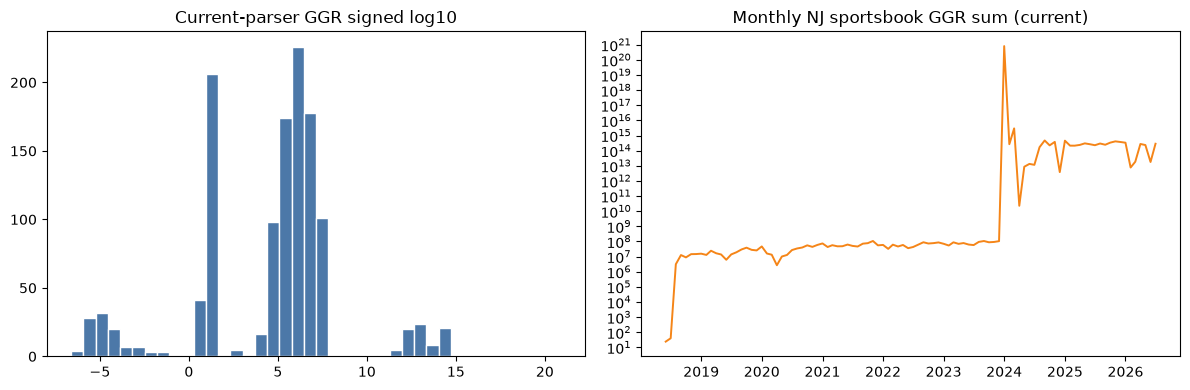

In [5]:
display(ggr.describe(percentiles=[0.5, 0.9, 0.99]).to_frame("gross_revenue"))
largest = nj.nlargest(8, "gross_revenue")[["period_start", "operator", "gross_revenue", "source_file"]]
smallest = nj.nsmallest(8, "gross_revenue")[["period_start", "operator", "gross_revenue", "source_file"]]
display(largest)
display(smallest)
monthly = nj.groupby("period_start_dt", as_index=False)["gross_revenue"].sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
signed_log = np.sign(ggr) * np.log10(ggr.abs().clip(lower=1))
axes[0].hist(signed_log.dropna(), bins=40, color="#4c78a8", edgecolor="white")
axes[0].set_title("Current-parser GGR signed log10")
axes[1].plot(monthly["period_start_dt"], monthly["gross_revenue"], color="#f58518", lw=1.4)
axes[1].set_yscale("symlog")
axes[1].set_title("Monthly NJ sportsbook GGR sum (current)")
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
fig.tight_layout()
plt.show()


## 6. Provenance validation

**What:** Every distinct source path must remain under `data/raw/NJ`, exist, and match `source_sha256`.

**Failure:** missing / outside-root / hash mismatch (fail closed).


In [6]:
def resolve_nj_source(rel: str) -> Path:
    path = (ROOT / rel).resolve()
    if NJ_RAW_ROOT not in path.parents and path != NJ_RAW_ROOT:
        raise AssertionError(f"path escapes NJ raw root: {path}")
    return path

source_meta = (
    nj.groupby(["source_file", "source_sha256", "source_url"], dropna=False)
    .agg(period_min=("period_start", "min"), period_max=("period_start", "max"), n_rows=("operator", "size"))
    .reset_index()
)
prov_rows = []
for row in source_meta.itertuples(index=False):
    status, actual, detail = "ok", None, None
    try:
        path = resolve_nj_source(row.source_file)
        if not path.is_file():
            status, detail = "missing", "file not found"
        else:
            actual = hashlib.sha256(path.read_bytes()).hexdigest()
            if actual != row.source_sha256:
                status, detail = "hash_mismatch", f"actual={actual}"
    except AssertionError as exc:
        status, detail = "outside_root", str(exc)
        path = ROOT / row.source_file
    prov_rows.append(
        {
            "period_min": row.period_min,
            "period_max": row.period_max,
            "source_file": row.source_file,
            "filename": Path(row.source_file).name,
            "source_url": row.source_url,
            "expected_sha256": row.source_sha256,
            "actual_sha256": actual,
            "status": status,
            "detail": detail,
            "n_rows": row.n_rows,
        }
    )
provenance = pd.DataFrame(prov_rows).sort_values(["period_min", "filename"])
display(provenance["status"].value_counts().to_frame("sources"))
assert provenance[provenance["status"] != "ok"].empty
print("provenance_ok", len(provenance))


,sources
status,
ok,98


provenance_ok 98


## 7. Shared cell semantics (demonstrated before layout prototypes)

**What:** Explicit source-cell interpretation used by both tax and skin prototypes.

| Cell content | Arithmetic value | Flags |
| --- | --- | --- |
| numeric (incl. `0`) | that number | `was_dash=False` |
| `(1,234)` / parentheses | negative | `was_dash=False` |
| `-`, `$ -` | **0.0** | `was_dash=True` (diagnostic) |
| empty / ambiguous | unresolved (`None`) | not coerced to zero |

**Tradeoff:** Treating an explicit dash as arithmetic zero matches the form’s “no amount” meaning for reconciliation, while retaining `was_dash` and the raw cell string so dash-vs-zero is auditable. Structurally absent cells stay unresolved.


In [7]:
DASH_ONLY = re.compile(r"^\$?\s*-\s*$")


def parse_source_cell(cell) -> dict:
    raw = "" if cell is None else str(cell).replace(chr(10), " ")
    text = _cell_text(raw)
    if text == "":
        return {"value": None, "was_dash": False, "raw": raw, "status": "absent"}
    if DASH_ONLY.match(text) or text in {"$-", "($-", "($-)"}:
        return {"value": 0.0, "was_dash": True, "raw": text, "status": "dash_zero"}
    vals = money_tokens(text)
    numeric = [v for v in vals if v is not None]
    if len(numeric) == 1:
        return {"value": float(numeric[0]), "was_dash": False, "raw": text, "status": "numeric"}
    if vals and all(v is None for v in vals):
        return {"value": 0.0, "was_dash": True, "raw": text, "status": "dash_zero"}
    return {"value": None, "was_dash": False, "raw": text, "status": "ambiguous"}


for sample in ["$ -", "-", "0", "$ 0", "(6,295)", "8 0,725,429", "", None, "$ 1,234"]:
    print(repr(sample), "->", parse_source_cell(sample))


'$ -' -> {'value': 0.0, 'was_dash': True, 'raw': '$ -', 'status': 'dash_zero'}
'-' -> {'value': 0.0, 'was_dash': True, 'raw': '-', 'status': 'dash_zero'}
'0' -> {'value': 0.0, 'was_dash': False, 'raw': '0', 'status': 'numeric'}
'$ 0' -> {'value': 0.0, 'was_dash': False, 'raw': '$ 0', 'status': 'numeric'}
'(6,295)' -> {'value': -6295.0, 'was_dash': False, 'raw': '(6,295)', 'status': 'numeric'}
'8 0,725,429' -> {'value': 80725429.0, 'was_dash': False, 'raw': '8 0,725,429', 'status': 'numeric'}
'' -> {'value': None, 'was_dash': False, 'raw': '', 'status': 'absent'}
None -> {'value': None, 'was_dash': False, 'raw': '', 'status': 'absent'}
'$ 1,234' -> {'value': 1234.0, 'was_dash': False, 'raw': '$ 1,234', 'status': 'numeric'}


## 8. Defect B — tax-page `_first_amount` line-number leakage

**What:** For tax layouts (June 2018–December 2023), when the official value cell is a dash, `_first_amount` finds no numeric tokens after the label and **falls back to the whole flattened line**, capturing the form line number (e.g. `8`, `15`, `16`) and sometimes `13` from `13%`.

**Cases required:**
- June 2018: dash → GGR `8`, tax `14`
- June 2019: dash → GGR `15`, tax `13` (on a dash page)
- December 2023: dash → GGR `16`, tax `13`

**Inspect:** raw line, substring after label, after-label tokens, whole-line tokens, current parse, table cell truth.


In [8]:
def pick_source(period: str) -> pd.Series:
    hit = provenance[provenance["period_min"] == period]
    assert not hit.empty, period
    return hit.iloc[0]


tax_cases = {
    "2018-06": pick_source("2018-06-01"),
    "2019-06": pick_source("2019-06-01"),
    "2023-12": pick_source("2023-12-01"),
}

TAX_GGR_LABELS = SPORTS_GGR_LABELS
TAX_TAX_LABELS = SPORTS_TAX_LABELS


def demonstrate_first_amount_defect(pdf_path: Path, want_dash_ggr: bool = True):
    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for pi, page in enumerate(pdf.pages):
            text = page.extract_text() or ""
            if _classify_nj_page(text) != "sports_tax":
                continue
            # Find a GGR line
            for raw in text.splitlines():
                for lab in TAX_GGR_LABELS:
                    if lab.casefold() not in raw.casefold():
                        continue
                    idx = raw.casefold().find(lab.casefold())
                    rest = raw[idx + len(lab) :]
                    after = money_tokens(rest)
                    whole = money_tokens(raw)
                    after_num = [v for v in after if v is not None]
                    # Prefer a dash example when requested
                    is_dashish = (not after_num) and any(v is None for v in after)
                    if want_dash_ggr and after_num:
                        continue
                    ggr, gl = _first_amount(text, TAX_GGR_LABELS)
                    tax, tl = _first_amount(text, TAX_TAX_LABELS)
                    parsed = parse_sports_tax_page(text)
                    # table truth
                    tables = page.extract_tables() or []
                    cell_truth = None
                    for table in tables:
                        for row in table or []:
                            if not row or len(row) < 2:
                                continue
                            desc = _cell_text(str(row[1] or "").replace(chr(10), " "))
                            if lab.casefold() in desc.casefold():
                                cell_truth = parse_source_cell(row[-1] if row[-1] not in (None, "") else row[-1])
                                # prefer last content cell
                                for c in reversed(row[2:]):
                                    if _cell_text(str(c or "")):
                                        cell_truth = parse_source_cell(c)
                                        break
                                break
                        if cell_truth is not None:
                            break
                    rows.append(
                        {
                            "page": pi + 1,
                            "raw_line": raw,
                            "label": lab,
                            "after_label": rest,
                            "tokens_after_label": after,
                            "tokens_whole_line": whole,
                            "current_ggr": ggr,
                            "current_tax": tax,
                            "parsed_operator": None if not parsed else parsed.get("operator"),
                            "table_cell_raw": None if not cell_truth else cell_truth["raw"],
                            "table_cell_value": None if not cell_truth else cell_truth["value"],
                            "table_was_dash": None if not cell_truth else cell_truth["was_dash"],
                            "correct_interpretation": (
                                "arithmetic 0.0 with was_dash=True"
                                if cell_truth and cell_truth["was_dash"]
                                else cell_truth
                            ),
                        }
                    )
                    return rows
    return rows


demo_frames = []
expectations = {
    "2018-06": {"ggr": 8.0, "tax": 14.0},
    "2019-06": {"ggr": 15.0, "tax": 13.0},
    "2023-12": {"ggr": 16.0, "tax": 13.0},
}
for key, meta in tax_cases.items():
    path = resolve_nj_source(meta["source_file"])
    demo = demonstrate_first_amount_defect(path, want_dash_ggr=True)
    assert demo, key
    row = demo[0]
    print("=" * 88)
    print(key, meta["filename"], "page", row["page"], "operator", row["parsed_operator"])
    print("raw_line:", row["raw_line"])
    print("after_label:", repr(row["after_label"]))
    print("tokens_after_label:", row["tokens_after_label"])
    print("tokens_whole_line:", row["tokens_whole_line"])
    print("current_ggr/tax:", row["current_ggr"], row["current_tax"])
    print("table_cell:", row["table_cell_raw"], "->", row["table_cell_value"], "was_dash", row["table_was_dash"])
    assert row["current_ggr"] == expectations[key]["ggr"], (key, row["current_ggr"])
    assert row["current_tax"] == expectations[key]["tax"], (key, row["current_tax"])
    assert row["table_was_dash"] is True
    assert row["table_cell_value"] == 0.0
    demo_frames.append({"case": key, **{k: row[k] for k in row}})

display(pd.DataFrame(demo_frames)[
    ["case", "page", "parsed_operator", "current_ggr", "current_tax", "table_cell_raw", "table_cell_value", "table_was_dash"]
])
print("tax_first_amount_defect_confirmed", True)


2018-06 b458b31a59d903a61077018d9ae666c7a3a245b7b96f6f9f6acf86b092b8cf13_June2018.pdf page 1 operator BORGATA HOTEL CASINO & SPA
raw_line: 8 Current Month Internet Sports Wagering Gross Revenue $ -
after_label: ' $ -'
tokens_after_label: [None]
tokens_whole_line: [8.0, None]
current_ggr/tax: 8.0 14.0
table_cell: $ - -> 0.0 was_dash True


2019-06 ee43636b83c54926ccef2f17227186c1625cf7436ab9974fe9774baa505defba_June2019.pdf page 2 operator BALLY'S PARK PLACE, LLC
raw_line: 15 Monthly Internet Sports Wagering Gross Revenue $ -
after_label: ' $ -'
tokens_after_label: [None]
tokens_whole_line: [15.0, None]
current_ggr/tax: 15.0 13.0
table_cell: $ - -> 0.0 was_dash True


2023-12 83b59df15ab5d592070fcfc32570aedff6b3c8cef5e4cedfb1c1fd0f6b73cb51_December2023.pdf page 3 operator CAESARS ATLANTIC CITY
raw_line: 16 Monthly Internet Sports Wagering Gross Revenue -
after_label: ' -'
tokens_after_label: [None]
tokens_whole_line: [16.0, None]
current_ggr/tax: 16.0 13.0
table_cell: - -> 0.0 was_dash True


,case,page,parsed_operator,current_ggr,current_tax,table_cell_raw,table_cell_value,table_was_dash
0,2018-06,1,BORGATA HOTEL CASINO & SPA,8.00,14.00,$ -,0.00,True
1,2019-06,2,"BALLY'S PARK PLACE, LLC",15.00,13.00,$ -,0.00,True
2,2023-12,3,CAESARS ATLANTIC CITY,16.00,13.00,-,0.00,True


tax_first_amount_defect_confirmed True


## 9. Defect A — skin-table cross-column concatenation (January 2024)

**What:** Reproduce the enormous Fanduel value and show whole-row repair vs per-cell tokens on page 24.

**Inspect:** flattened line, `repair_pdf_line`, `money_tokens`, cell-wise tokens, SQLite match.


In [9]:
jan = pick_source("2024-01-01")
JAN_PDF = resolve_nj_source(jan["source_file"])
assert jan["expected_sha256"] == "6b4c31926fcc009315f70fcc7f14ed13ee61143d6e5abf2fd37fc1af6e3a4e83"
assert hashlib.sha256(JAN_PDF.read_bytes()).hexdigest() == jan["expected_sha256"]

parsed_jan = parse_nj_pdf(JAN_PDF, vertical=SPORTS_VERTICAL)
fan_parsed = parsed_jan[parsed_jan["operator"].str.contains("anduel", case=False, na=False)]
fan_db = nj[(nj["period_start"] == "2024-01-01") & nj["operator"].str.contains("anduel", case=False, na=False)]
display(fan_parsed[["operator", "gross_revenue"]])
display(fan_db[["operator", "gross_revenue", "source_sha256"]])
assert abs(float(fan_parsed["gross_revenue"].iloc[0]) - float(fan_db["gross_revenue"].iloc[0])) < 1e-6
assert float(fan_parsed["gross_revenue"].iloc[0]) > 1e18
print("january_2024_defect_reproduced", True)

with pdfplumber.open(JAN_PDF) as pdf:
    page24 = pdf.pages[23]
    tables = page24.extract_tables() or []
    assert tables
    # search all tables for line 16 monthly GGR
    row16 = None
    header = None
    for table in tables:
        header = table[0]
        for row in table[1:]:
            if row and str(row[0]).strip() == "16" and "Monthly Online Sports Wagering Gross Revenue" in str(row[1] or ""):
                row16 = row
                break
        if row16:
            break
assert row16 is not None
flat = " ".join((str(c).replace(chr(10), " ") if c else "") for c in row16)
print("header", header)
print("row16", row16)
print("flattened:", flat)
print("repair_pdf_line:", repair_pdf_line(flat))
print("money_tokens(whole):", money_tokens(flat))
for i in range(2, len(row16)):
    print(" cell", header[i] if i < len(header) else i, "->", parse_source_cell(row16[i]))
assert any(t and t > 1e18 for t in money_tokens(flat) if t is not None)
assert parse_source_cell("8 0,725,429")["value"] == 80_725_429
assert parse_source_cell("2 8,541,559")["value"] == 28_541_559
assert parse_source_cell("4 5,791")["value"] == 45_791
assert parse_source_cell("1 09,312,779")["value"] == 109_312_779
print("cross_column_concatenation_confirmed", True)


,operator,gross_revenue
4,Fanduel,8.072543e+20


,operator,gross_revenue,source_sha256
877,Fanduel,8.072543e+20,6b4c31926fcc009315f70fcc7f14ed13ee61143d6e5abf...


january_2024_defect_reproduced True
header ['Line', 'Description', 'Fanduel\nGross Revenue', 'Pointsbet\nGross Revenue', 'SuperBook\nGross Revenue', 'Total\nGross Revenue']
row16 ['16', 'Monthly Online Sports Wagering Gross Revenue', '8 0,725,429', '2 8,541,559', '4 5,791', '1 09,312,779']
flattened: 16 Monthly Online Sports Wagering Gross Revenue 8 0,725,429 2 8,541,559 4 5,791 1 09,312,779
repair_pdf_line: 16 Monthly Online Sports Wagering Gross Revenue 80,725,42928,541,55945,791 109,312,779
money_tokens(whole): [16.0, 8.072542928541559e+20, 109312779.0]
 cell Fanduel
Gross Revenue -> {'value': 80725429.0, 'was_dash': False, 'raw': '8 0,725,429', 'status': 'numeric'}
 cell Pointsbet
Gross Revenue -> {'value': 28541559.0, 'was_dash': False, 'raw': '2 8,541,559', 'status': 'numeric'}
 cell SuperBook
Gross Revenue -> {'value': 45791.0, 'was_dash': False, 'raw': '4 5,791', 'status': 'numeric'}
 cell Total
Gross Revenue -> {'value': 109312779.0, 'was_dash': False, 'raw': '1 09,312,779', '

## 10. Layout-specific prototypes (notebook-local only)

### Tax prototype
- Search **every** extracted table for the online/internet sports GGR description.
- Parse **only** the value cell via `parse_source_cell`.
- Never fall back to whole-line tokenisation.
- Emit operator-level rows with raw cell + `was_dash`.

### Skin prototype
- Search **every** table for the monthly online sports GGR row.
- Align header brands (including empty placeholder columns) to monetary cells.
- Identify Total deliberately.
- All-dash operators **and** dash Total → `pass_zero` (arithmetic zeros with `was_dash`).
- Otherwise reconcile operator sum to Total within $1 → `pass` / `fail_reconcile`.
- No flattened-text fallback.


In [10]:
SKIN_GGR_LABELS = SPORTS_SKIN_GGR_LABELS + (
    "Monthly Internet Sports Wagering Gross Revenue",
    "Current Month Internet Sports Wagering Gross Revenue",
)


def header_brands(header_row) -> list[str | None]:
    names: list[str | None] = []
    for cell in header_row[2:]:
        text = _cell_text(str(cell).replace(chr(10), " ") if cell else "")
        cleaned = re.sub(r"\bGross Revenue\b", "", text, flags=re.I)
        cleaned = re.sub(r"\bWin\b", "", cleaned, flags=re.I)
        cleaned = _cell_text(cleaned)
        if cleaned.casefold() == "total":
            names.append("Total")
        elif cleaned:
            names.append(cleaned)
        else:
            names.append(None)
    return names


def find_row_in_tables(tables, pred):
    for ti, table in enumerate(tables or []):
        if not table:
            continue
        for row in table[1:]:
            if row and len(row) > 1 and pred(row, table[0]):
                return ti, table[0], row
    return None, None, None


def prototype_tax_pdf(path: Path) -> dict:
    pages_out = []
    tax_pages = 0
    with pdfplumber.open(path) as pdf:
        period = None
        for pi, page in enumerate(pdf.pages):
            text = page.extract_text() or ""
            pp = _page_period(text)
            if pp:
                period = pp
            if _classify_nj_page(text) != "sports_tax":
                continue
            tax_pages += 1
            tables = page.extract_tables() or []
            ti, header, row = find_row_in_tables(
                tables,
                lambda r, h: any(
                    lab.casefold() in _cell_text(str(r[1] or "").replace(chr(10), " ")).casefold()
                    for lab in TAX_GGR_LABELS
                ),
            )
            if row is None:
                # Minimal exclusion: retail GGR label present AND no supported online/internet GGR label.
                retail_markers = (
                    "Retail Sports Wagering Gross Revenue",
                    "Monthly Retail Sports Wagering Gross Revenue",
                    "Current Month Sports Wagering Gross Revenue",
                )
                text_cf = text.casefold()
                has_online_label = any(lab.casefold() in text_cf for lab in TAX_GGR_LABELS)
                has_retail_label = any(m.casefold() in text_cf for m in retail_markers)
                if has_retail_label and not has_online_label:
                    pages_out.append(
                        {
                            "page": pi + 1,
                            "status": "excluded_retail",
                            "reason": "retail_only_no_online_ggr_row",
                            "period": period,
                        }
                    )
                else:
                    pages_out.append(
                        {
                            "page": pi + 1,
                            "status": "fail_structure",
                            "reason": "no_ggr_row_in_any_table",
                            "period": period,
                        }
                    )
                continue
            # description label
            desc = _cell_text(str(row[1] or "").replace(chr(10), " "))
            label = next(lab for lab in TAX_GGR_LABELS if lab.casefold() in desc.casefold())
            value_cell = None
            for c in reversed(row[2:]):
                if c is not None and _cell_text(str(c)) != "":
                    value_cell = c
                    break
            if value_cell is None and len(row) > 2:
                value_cell = row[-1]
            parsed = parse_source_cell(value_cell)
            if parsed["status"] in {"absent", "ambiguous"}:
                pages_out.append(
                    {
                        "page": pi + 1,
                        "status": "fail_structure",
                        "reason": f"value_cell_{parsed['status']}",
                        "period": period,
                        "raw": parsed["raw"],
                        "label": label,
                    }
                )
                continue
            entity_lines = text.splitlines()
            # light entity: first non-empty lines before MONTHLY/FOR THE
            from variant_gaming.states.new_jersey import _entity_name

            operator = _entity_name(entity_lines)
            pages_out.append(
                {
                    "page": pi + 1,
                    "status": "pass",
                    "reason": None,
                    "period": period,
                    "operator": operator,
                    "label": label,
                    "gross_revenue": parsed["value"],
                    "was_dash": parsed["was_dash"],
                    "raw_cell": parsed["raw"],
                    "table_index": ti,
                }
            )
    return {"layout": "tax", "pages": pages_out, "n_layout_pages": tax_pages}


def prototype_skin_pdf(path: Path) -> dict:
    pages_out = []
    skin_pages = 0
    with pdfplumber.open(path) as pdf:
        period = None
        for pi, page in enumerate(pdf.pages):
            text = page.extract_text() or ""
            pp = _page_period(text)
            if pp:
                period = pp
            if _classify_nj_page(text) != "sports_skin":
                continue
            skin_pages += 1
            tables = page.extract_tables() or []
            ti, header, row = find_row_in_tables(
                tables,
                lambda r, h: any(
                    lab.casefold() in _cell_text(str(r[1] or "").replace(chr(10), " ")).casefold()
                    for lab in SKIN_GGR_LABELS
                ),
            )
            if row is None or header is None:
                pages_out.append({"page": pi + 1, "status": "fail_structure", "reason": "no_ggr_row_in_any_table", "period": period})
                continue
            brands = header_brands(header)
            total_idx = next((i for i, b in enumerate(brands) if b and b.casefold() == "total"), None)
            money_cells = list(row[2 : 2 + len(brands)])
            if total_idx is None or len(money_cells) != len(brands):
                pages_out.append(
                    {
                        "page": pi + 1,
                        "status": "fail_structure",
                        "reason": "cardinality_or_missing_total",
                        "period": period,
                        "n_brands": len(brands),
                        "n_cells": len(money_cells),
                    }
                )
                continue
            parsed_cells = [parse_source_cell(c) for c in money_cells]
            if any(p["status"] in {"absent", "ambiguous"} for p in parsed_cells):
                pages_out.append({"page": pi + 1, "status": "fail_structure", "reason": "ambiguous_or_absent_cell", "period": period})
                continue
            values = [p["value"] for p in parsed_cells]
            dashes = [p["was_dash"] for p in parsed_cells]
            total = values[total_idx]
            ops = [
                {
                    "brand": b,
                    "value": v,
                    "was_dash": d,
                    "raw": parsed_cells[i]["raw"],
                }
                for i, (b, v, d) in enumerate(zip(brands, values, dashes))
                if i != total_idx and b is not None
            ]
            op_sum = float(sum(o["value"] for o in ops))
            all_dash = all(d for d in dashes)
            label = next(
                lab
                for lab in SKIN_GGR_LABELS
                if lab.casefold() in _cell_text(str(row[1] or "").replace(chr(10), " ")).casefold()
            )
            if all_dash:
                # explicit all-dash row: Total and operators are arithmetic zero
                pages_out.append(
                    {
                        "page": pi + 1,
                        "status": "pass_zero",
                        "reason": None,
                        "period": period,
                        "label": label,
                        "brands": brands,
                        "ops": ops,
                        "total": 0.0,
                        "op_sum": 0.0,
                        "delta": 0.0,
                        "table_index": ti,
                        "all_dash": True,
                    }
                )
                continue
            if total is None:
                pages_out.append({"page": pi + 1, "status": "fail_reconcile", "reason": "total_null", "period": period, "ops": ops})
                continue
            delta = abs(op_sum - float(total))
            status = "pass" if delta <= 1.0 else "fail_reconcile"
            pages_out.append(
                {
                    "page": pi + 1,
                    "status": status,
                    "reason": None if status == "pass" else f"delta={delta}",
                    "period": period,
                    "label": label,
                    "brands": brands,
                    "ops": ops,
                    "total": float(total),
                    "op_sum": op_sum,
                    "delta": delta,
                    "table_index": ti,
                    "all_dash": False,
                }
            )
    return {"layout": "skin", "pages": pages_out, "n_layout_pages": skin_pages}


# January 2024 skin assertions
jan_skin = prototype_skin_pdf(JAN_PDF)
p24 = next(p for p in jan_skin["pages"] if p["page"] == 24)
op_map = {o["brand"]: o["value"] for o in p24["ops"]}
assert op_map["Fanduel"] == 80_725_429
assert op_map["Pointsbet"] == 28_541_559
assert op_map["SuperBook"] == 45_791
assert p24["total"] == 109_312_779
assert abs(p24["op_sum"] - p24["total"]) <= 1
assert all(p["status"] in {"pass", "pass_zero"} for p in jan_skin["pages"])
print("january_skin_prototype_ok", True)

# June 2018 tax assertions: all dashes -> 0
june2018 = prototype_tax_pdf(resolve_nj_source(tax_cases["2018-06"]["source_file"]))
assert june2018["n_layout_pages"] >= 1
assert all(p["status"] == "pass" for p in june2018["pages"])
assert all(p["gross_revenue"] == 0.0 and p["was_dash"] for p in june2018["pages"])
print("june2018_tax_prototype_ok", True, "pages", len(june2018["pages"]))


january_skin_prototype_ok True


june2018_tax_prototype_ok True pages 3


## 11. Audit all 98 retained sportsbook sources

**Rules:**
- Prefer **skin** layout when any sports-skin page exists; otherwise use **tax** layout.
- Tax success = structural cell parse on each tax page (no line-number leakage). Tax pages lack a document-level Total invariant comparable to skins.
- Skin success = `pass` or `pass_zero` on every skin page with GGR row found.
- Fail closed; no flattened-text fallback.

**Inspect:** status counts by layout; full unresolved table.


In [11]:
def summarize_file(path: Path) -> dict:
    # detect layouts present
    has_skin = has_tax = False
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            kind = _classify_nj_page(page.extract_text() or "")
            if kind == "sports_skin":
                has_skin = True
            elif kind == "sports_tax":
                has_tax = True
    if has_skin:
        result = prototype_skin_pdf(path)
    elif has_tax:
        result = prototype_tax_pdf(path)
    else:
        return {
            "layout_type": "unknown",
            "pages_examined": 0,
            "status": "fail_structure",
            "failure_reason": "no_sports_tax_or_skin_pages",
            "numeric_rows": 0,
            "dash_rows": 0,
            "negative_rows": 0,
            "structural_failures": 1,
            "pages": [],
            "proto_rows": [],
        }

    pages = result["pages"]
    layout = result["layout"]
    if result["n_layout_pages"] == 0:
        status, reason = "fail_structure", "layout_pages_zero"
    elif layout == "tax":
        excluded = [p for p in pages if p["status"] == "excluded_retail"]
        online_pages = [p for p in pages if p["status"] != "excluded_retail"]
        bad = [p for p in online_pages if p["status"] != "pass"]
        if not online_pages:
            status, reason = "fail_structure", "no_online_tax_pages"
        elif not bad:
            status, reason = "pass", None
        else:
            status, reason = "fail_structure", bad[0].get("reason")
    else:
        ok = {"pass", "pass_zero"}
        bad = [p for p in pages if p["status"] not in ok]
        if not pages:
            status, reason = "fail_structure", "no_skin_ggr_rows"
        elif not bad and all(p["status"] == "pass_zero" for p in pages):
            status, reason = "pass_zero", None
        elif not bad:
            status, reason = "pass", None
        elif any(p["status"] == "fail_structure" for p in pages):
            status, reason = "fail_structure", next(p for p in bad if p["status"] == "fail_structure").get("reason")
        else:
            status, reason = "fail_reconcile", bad[0].get("reason")

    numeric_rows = dash_rows = negative_rows = 0
    proto_rows = []
    if layout == "tax":
        for p in pages:
            if p.get("status") != "pass":
                continue
            if p.get("was_dash"):
                dash_rows += 1
            elif p.get("gross_revenue") is not None and p["gross_revenue"] != 0:
                numeric_rows += 1
            if p.get("gross_revenue") is not None and p["gross_revenue"] < 0:
                negative_rows += 1
            year, month = p["period"]
            proto_rows.append(
                {
                    "period_start": f"{year:04d}-{month:02d}-01",
                    "operator": p["operator"],
                    "gross_revenue": p["gross_revenue"],
                    "was_dash": p["was_dash"],
                    "raw_cell": p["raw_cell"],
                    "layout_type": "tax",
                    "page": p["page"],
                }
            )
    else:
        for p in pages:
            if p.get("status") not in {"pass", "pass_zero"}:
                continue
            for o in p.get("ops", []):
                if o["was_dash"]:
                    dash_rows += 1
                elif o["value"] != 0:
                    numeric_rows += 1
                if o["value"] < 0:
                    negative_rows += 1
                if o["value"] == 0 and not o["was_dash"]:
                    pass
                # retain zeros that are not dash? keep non-zero and dash and negatives; skip plain zero without dash to mirror current skip-zero? 
                # Keep all named operator cells including zero/dash for comparison completeness.
                year, month = p["period"]
                proto_rows.append(
                    {
                        "period_start": f"{year:04d}-{month:02d}-01",
                        "operator": o["brand"],
                        "gross_revenue": o["value"],
                        "was_dash": o["was_dash"],
                        "raw_cell": o["raw"],
                        "layout_type": "skin",
                        "page": p["page"],
                    }
                )

    structural_failures = sum(1 for p in pages if p.get("status") == "fail_structure")
    excluded_retail_pages = sum(1 for p in pages if p.get("status") == "excluded_retail")
    return {
        "layout_type": layout,
        "pages_examined": result["n_layout_pages"],
        "status": status,
        "failure_reason": reason,
        "numeric_rows": numeric_rows,
        "dash_rows": dash_rows,
        "negative_rows": negative_rows,
        "structural_failures": structural_failures,
        "excluded_retail_pages": excluded_retail_pages,
        "pages": pages,
        "proto_rows": proto_rows,
        "relevant_pages": ",".join(str(p["page"]) for p in pages) if pages else None,
    }


audit_rows = []
proto_all_rows = []
for row in provenance.itertuples(index=False):
    path = resolve_nj_source(row.source_file)
    summary = summarize_file(path)
    audit_rows.append(
        {
            "period": row.period_min,
            "source_filename": row.filename,
            "source_hash": row.expected_sha256,
            "source_file": row.source_file,
            "layout_type": summary["layout_type"],
            "pages_examined": summary["pages_examined"],
            "relevant_pages": summary["relevant_pages"],
            "numeric_rows": summary["numeric_rows"],
            "dash_rows": summary["dash_rows"],
            "negative_rows": summary["negative_rows"],
            "structural_failures": summary["structural_failures"],
            "excluded_retail_pages": summary.get("excluded_retail_pages", 0),
            "status": summary["status"],
            "failure_reason": summary["failure_reason"],
        }
    )
    for pr in summary["proto_rows"]:
        proto_all_rows.append({**pr, "source_sha256": row.expected_sha256, "source_file": row.source_file})

source_audit = pd.DataFrame(audit_rows).sort_values(["period", "source_filename"]).reset_index(drop=True)
proto_all = pd.DataFrame(proto_all_rows)

print("status_by_layout")
display(pd.crosstab(source_audit["layout_type"], source_audit["status"]))
print("overall_status")
display(source_audit["status"].value_counts().to_frame("files"))

tax_files = source_audit[source_audit["layout_type"] == "tax"]
skin_files = source_audit[source_audit["layout_type"] == "skin"]
print("tax_pass", int((tax_files["status"] == "pass").sum()), "/", len(tax_files))
print("skin_pass_like", int(skin_files["status"].isin(["pass", "pass_zero"]).sum()), "/", len(skin_files))
print("all98_pass_like", int(source_audit["status"].isin(["pass", "pass_zero"]).sum()), "/", len(source_audit))
print("excluded_retail_pages_total", int(source_audit["excluded_retail_pages"].fillna(0).sum()))

unresolved = source_audit[~source_audit["status"].isin(["pass", "pass_zero"])]
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(unresolved[["period", "source_filename", "layout_type", "status", "failure_reason", "pages_examined"]])


status_by_layout


status,pass
layout_type,
skin,31
tax,67


overall_status


,files
status,
pass,98


tax_pass 67 / 67
skin_pass_like 31 / 31
all98_pass_like 98 / 98
excluded_retail_pages_total 14


,period,source_filename,layout_type,status,failure_reason,pages_examined


## 12. Current vs prototype comparison

**What:** Compare current SQLite rows to prototype rows on auditable sources.

**Primary alignment:** exact operator labels `(period_start, source_sha256, operator)`.

**Casefold:** diagnostic only. Casefold collisions exist (identifier limitation); do not treat casefolding as a collision-free key and do not normalize operators.

**Inspect:** aligned / current-only / prototype-only / mismatches / leakage / concatenations; plus the concise prototype-only skin-row accounting.


prototype_casefold_collisions 5


,period_start,source_sha256,operator_cf,n_labels
735,2023-03-01,62fbc1635831f910d3116ca2a963a828145844b76ec732cb25fcd7f751ce638a,tropicana casino & resort,2
750,2023-04-01,682e8e2cdca64dc8fc8e1bfaf615bc7014bc7d350fe2d911a350181e3aa77b9f,tropicana casino & resort,2
765,2023-05-01,24d02b78cc63d1e769efdb56ae1d0672d8489de99008d25e43bd8a5a96897d37,tropicana casino & resort,2
1398,2026-06-01,80e37f93916b90f3fcf615e9314e3beeeba9cee2873e3ede26a1c5bb2d3d7e2a,prime,2
1414,2026-07-01,0ad99b946e4cde9687a50e6294db1908503ed96bdbb62f54a38de6bcdd415c05,prime,2


current_casefold_collisions 4


,period_start,source_sha256,operator_cf,n_labels
735,2023-03-01,62fbc1635831f910d3116ca2a963a828145844b76ec732cb25fcd7f751ce638a,tropicana casino & resort,2
750,2023-04-01,682e8e2cdca64dc8fc8e1bfaf615bc7014bc7d350fe2d911a350181e3aa77b9f,tropicana casino & resort,2
765,2023-05-01,24d02b78cc63d1e769efdb56ae1d0672d8489de99008d25e43bd8a5a96897d37,tropicana casino & resort,2
1217,2026-06-01,80e37f93916b90f3fcf615e9314e3beeeba9cee2873e3ede26a1c5bb2d3d7e2a,prime,2


aligned 1234
prototype_only 188
current_only 0
prototype_only_skin 188 prototype_only_tax 0
skin_proto_only_dash_or_zero 61
skin_proto_only_nonzero_missing_from_current_consistent_with_truncated_zip 127


...

Note: casefold collisions exist as an identifier limitation; primary comparison uses exact operator labels (no normalization).
value_mismatches 350


,period_start,operator,operator_current,gross_revenue_current,gross_revenue_proto,abs_diff,line_number_leakage,likely_concat,was_dash,layout_type
881,2024-01-01,Fanduel,Fanduel,8.072543e+20,"80,725,429.00",8.072543e+20,False,True,False,skin
920,2024-03-01,Fanduel,Fanduel,2.953389e+15,"29,533,888.00",2.953389e+15,False,True,False,skin
1284,2025-11-01,DraftKings,DraftKings,3.833892e+14,"38,338,924.00",3.833892e+14,False,True,False,skin
1042,2024-09-01,DRAFTKINGS,DRAFTKINGS,3.656990e+14,"36,569,895.00",3.656989e+14,False,True,False,skin
1082,2024-11-01,DraftKings,DraftKings,3.564193e+14,"35,641,932.00",3.564193e+14,False,True,False,skin
1124,2025-01-01,DraftKings,DraftKings,3.564085e+14,"35,640,850.00",3.564085e+14,False,True,False,skin
1301,2025-12-01,DraftKings,DraftKings,3.401874e+14,"34,018,744.00",3.401874e+14,False,True,False,skin
1317,2026-01-01,DraftKings,DraftKings,3.059891e+14,"30,598,912.00",3.059891e+14,False,True,False,skin
1268,2025-10-01,DraftKings,DraftKings,3.052041e+14,"30,520,414.00",3.052041e+14,False,True,False,skin
1188,2025-05-01,DraftKings,DraftKings,2.830606e+14,"28,306,058.00",2.830606e+14,False,True,False,skin


leakage_mismatches 242 concat_mismatches 73


,period_start,source_sha256,operator,layout_type,gross_revenue_proto,was_dash,raw_cells,operator_cf_x,operator_current,operator_cf_y,gross_revenue_current,_merge,abs_diff,line_number_leakage,likely_concat
870,2023-12-01,83b59df15ab5d592070fcfc32570aedff6b3c8cef5e4ce...,RESORTS CASINO HOTEL (DGMB CASINO LLC),tax,0.00,True,-,resorts casino hotel (dgmb casino llc),RESORTS CASINO HOTEL (DGMB CASINO LLC),resorts casino hotel (dgmb casino llc),16.00,both,16.00,True,False
861,2023-12-01,83b59df15ab5d592070fcfc32570aedff6b3c8cef5e4ce...,CAESARS ATLANTIC CITY,tax,0.00,True,-,caesars atlantic city,CAESARS ATLANTIC CITY,caesars atlantic city,16.00,both,16.00,True,False
859,2023-12-01,83b59df15ab5d592070fcfc32570aedff6b3c8cef5e4ce...,BOARDWALK REGENCY (ONLINE),tax,0.00,True,-,boardwalk regency (online),BOARDWALK REGENCY (ONLINE),boardwalk regency (online),16.00,both,16.00,True,False
856,2023-11-01,88153201e86010f1ba614cbd6111a8c78249a57ae2b56a...,RESORTS CASINO HOTEL (DGMB CASINO LLC),tax,0.00,True,-,resorts casino hotel (dgmb casino llc),RESORTS CASINO HOTEL (DGMB CASINO LLC),resorts casino hotel (dgmb casino llc),16.00,both,16.00,True,False
847,2023-11-01,88153201e86010f1ba614cbd6111a8c78249a57ae2b56a...,CAESARS ATLANTIC CITY,tax,0.00,True,-,caesars atlantic city,CAESARS ATLANTIC CITY,caesars atlantic city,16.00,both,16.00,True,False
845,2023-11-01,88153201e86010f1ba614cbd6111a8c78249a57ae2b56a...,BOARDWALK REGENCY (ONLINE),tax,0.00,True,-,boardwalk regency (online),BOARDWALK REGENCY (ONLINE),boardwalk regency (online),16.00,both,16.00,True,False
791,2023-07-01,2846be17a1b661abc7cdc87759b983c47d8ddc1a3a9e84...,HARRAH'S ATLANTIC CITY,tax,0.00,True,-,harrah's atlantic city,HARRAH'S ATLANTIC CITY,harrah's atlantic city,16.00,both,16.00,True,False
786,2023-07-01,2846be17a1b661abc7cdc87759b983c47d8ddc1a3a9e84...,CAESARS ATLANTIC CITY,tax,0.00,True,-,caesars atlantic city,CAESARS ATLANTIC CITY,caesars atlantic city,16.00,both,16.00,True,False
781,2023-06-01,470648c1c425b874c2f8bc3107f7c674f768024b9309a3...,RESORTS CASINO HOTEL (DGMB CASINO LLC),tax,0.00,True,-,resorts casino hotel (dgmb casino llc),RESORTS CASINO HOTEL (DGMB CASINO LLC),resorts casino hotel (dgmb casino llc),16.00,both,16.00,True,False
776,2023-06-01,470648c1c425b874c2f8bc3107f7c674f768024b9309a3...,HARRAH'S ATLANTIC CITY,tax,0.00,True,-,harrah's atlantic city,HARRAH'S ATLANTIC CITY,harrah's atlantic city,16.00,both,16.00,True,False


,period_start,source_sha256,operator,layout_type,gross_revenue_proto,was_dash,raw_cells,operator_cf_x,operator_current,operator_cf_y,gross_revenue_current,_merge,abs_diff,line_number_leakage,likely_concat
881,2024-01-01,6b4c31926fcc009315f70fcc7f14ed13ee61143d6e5abf...,Fanduel,skin,"80,725,429.00",False,"8 0,725,429",fanduel,Fanduel,fanduel,8.072543e+20,both,8.072543e+20,False,True
920,2024-03-01,70f02b43d2a17b9263753360a0e993eb191e45c57f5277...,Fanduel,skin,"29,533,888.00",False,"2 9,533,888",fanduel,Fanduel,fanduel,2.953389e+15,both,2.953389e+15,False,True
1284,2025-11-01,5de9824e1306048c22e8302ebd272509283b2d56735492...,DraftKings,skin,"38,338,924.00",False,"38,338,924",draftkings,DraftKings,draftkings,3.833892e+14,both,3.833892e+14,False,True
1042,2024-09-01,eac0ce28d37de0d51b8bed1e025d1999371dd4e9c3a541...,DRAFTKINGS,skin,"36,569,895.00",False,"3 6,569,895",draftkings,DRAFTKINGS,draftkings,3.656990e+14,both,3.656989e+14,False,True
1082,2024-11-01,9a3c79cd47b928921c60b33e47c80558f58360a3d65f4c...,DraftKings,skin,"35,641,932.00",False,"3 5,641,932",draftkings,DraftKings,draftkings,3.564193e+14,both,3.564193e+14,False,True
1124,2025-01-01,d303db0b7b88e8a8a6a8291ba5abfee4b82dbbd7da4708...,DraftKings,skin,"35,640,850.00",False,"3 5,640,850",draftkings,DraftKings,draftkings,3.564085e+14,both,3.564085e+14,False,True
1301,2025-12-01,2b0a947763af202035c4f61d821b073364ae63540d1439...,DraftKings,skin,"34,018,744.00",False,"34,018,744",draftkings,DraftKings,draftkings,3.401874e+14,both,3.401874e+14,False,True
1317,2026-01-01,ce0ea6b8ec41a9959b3b3f3c5cc397b219ec25acaa0ac0...,DraftKings,skin,"30,598,912.00",False,"30,598,912",draftkings,DraftKings,draftkings,3.059891e+14,both,3.059891e+14,False,True
1268,2025-10-01,79065235f8b78976300ad8de6665ae6b8ff2a5780d6881...,DraftKings,skin,"30,520,414.00",False,"30,520,414",draftkings,DraftKings,draftkings,3.052041e+14,both,3.052041e+14,False,True
1188,2025-05-01,bc4daf8dfbc9dd819aa28db22f625d0e1df0ddfcb296f5...,DraftKings,skin,"28,306,058.00",False,"2 8,306,058",draftkings,DraftKings,draftkings,2.830606e+14,both,2.830606e+14,False,True


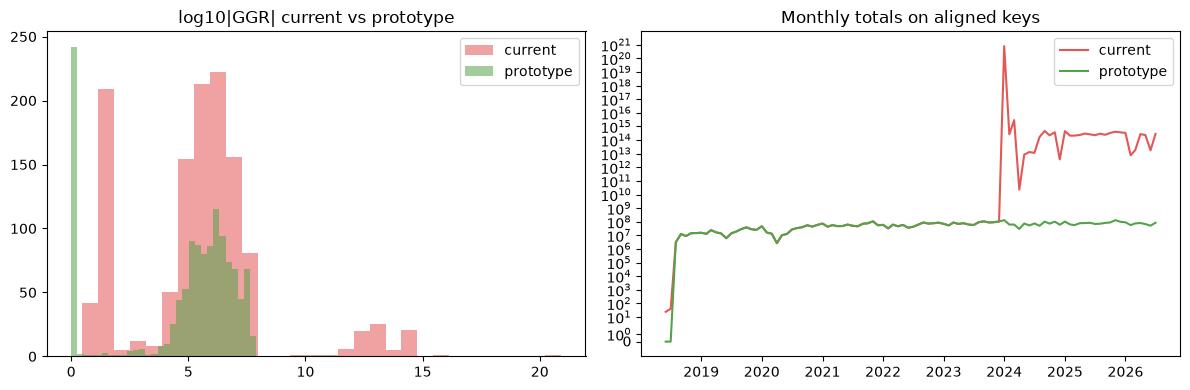

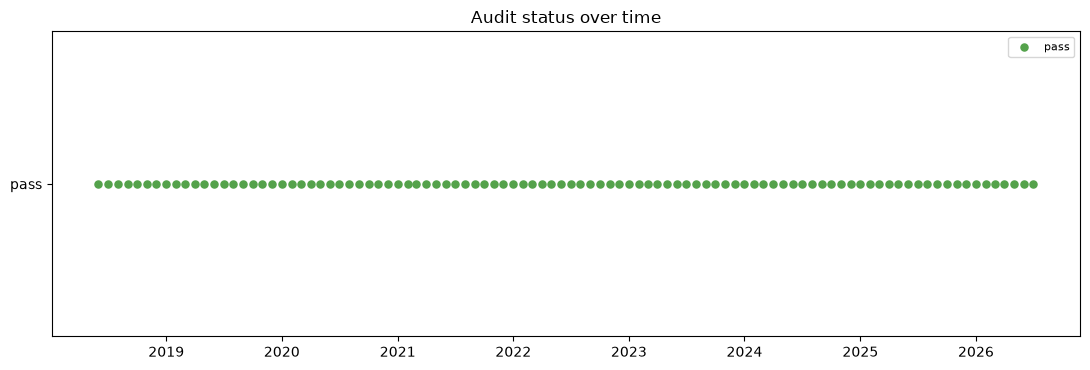

In [12]:
# Aggregate prototype operator rows (sum within source x period x operator label)
if proto_all.empty:
    raise AssertionError("prototype produced no rows")

proto_agg = (
    proto_all.groupby(["period_start", "source_sha256", "operator", "layout_type"], as_index=False)
    .agg(
        gross_revenue_proto=("gross_revenue", "sum"),
        was_dash=("was_dash", "any"),
        raw_cells=("raw_cell", lambda s: " | ".join(sorted(set(map(str, s))))),
    )
)
proto_agg["operator_cf"] = proto_agg["operator"].str.casefold()

# Casefold is diagnostic-only. Preserve evidence of collisions rather than forcing uniqueness.
coll = (
    proto_agg.groupby(["period_start", "source_sha256", "operator_cf"])["operator"]
    .nunique()
    .reset_index(name="n_labels")
)
proto_collisions = coll[coll["n_labels"] > 1]
print("prototype_casefold_collisions", len(proto_collisions))
with pd.option_context("display.max_rows", None, "display.max_colwidth", 80):
    display(proto_collisions)

cur = nj.copy()
cur["operator_cf"] = cur["operator"].str.casefold()
cur_coll = (
    cur.groupby(["period_start", "source_sha256", "operator_cf"])["operator"]
    .nunique()
    .reset_index(name="n_labels")
)
current_collisions = cur_coll[cur_coll["n_labels"] > 1]
print("current_casefold_collisions", len(current_collisions))
with pd.option_context("display.max_rows", None, "display.max_colwidth", 80):
    display(current_collisions)

# Primary alignment preserves original labels (exact operator string).
merged = proto_agg.merge(
    cur[["period_start", "source_sha256", "operator", "operator_cf", "gross_revenue"]].rename(
        columns={"gross_revenue": "gross_revenue_current", "operator": "operator_current"}
    ),
    left_on=["period_start", "source_sha256", "operator"],
    right_on=["period_start", "source_sha256", "operator_current"],
    how="outer",
    indicator=True,
)

merged["abs_diff"] = (merged["gross_revenue_proto"] - merged["gross_revenue_current"]).abs()
merged["line_number_leakage"] = (
    merged["was_dash"].fillna(False)
    & merged["gross_revenue_current"].isin([8, 14, 15, 13, 16, 18, 19, 20, 21])
)
merged["likely_concat"] = merged["gross_revenue_current"] > 1e12

print("aligned", int((merged["_merge"] == "both").sum()))
print("prototype_only", int((merged["_merge"] == "left_only").sum()))
print("current_only", int((merged["_merge"] == "right_only").sum()))

# Concise accounting of prototype-only skin rows (exact operator labels).
proto_only = merged[merged["_merge"] == "left_only"].copy()
skin_proto_only = proto_only[proto_only["layout_type"] == "skin"].copy()
tax_proto_only = proto_only[proto_only["layout_type"] == "tax"].copy()
print("prototype_only_skin", len(skin_proto_only), "prototype_only_tax", len(tax_proto_only))
skin_dash_zero = skin_proto_only[
    skin_proto_only["was_dash"].fillna(False) | (skin_proto_only["gross_revenue_proto"].fillna(0) == 0)
]
skin_nonzero_missing = skin_proto_only[
    (~skin_proto_only["was_dash"].fillna(False)) & (skin_proto_only["gross_revenue_proto"].fillna(0).abs() > 0)
]
print("skin_proto_only_dash_or_zero", len(skin_dash_zero))
print("skin_proto_only_nonzero_missing_from_current_consistent_with_truncated_zip", len(skin_nonzero_missing))
assert len(skin_dash_zero) + len(skin_nonzero_missing) == len(skin_proto_only)
display(
    pd.DataFrame(
        [
            {"bucket": "dash_or_zero_omitted_by_current", "n": len(skin_dash_zero)},
            {"bucket": "nonzero_missing_from_current_consistent_with_truncated_zip", "n": len(skin_nonzero_missing)},
            {"bucket": "skin_prototype_only_total", "n": len(skin_proto_only)},
        ]
    )
)
display(
    skin_nonzero_missing[
        ["period_start", "operator", "gross_revenue_proto", "was_dash", "raw_cells"]
    ].head(8)
)
print(
    "Note: casefold collisions exist as an identifier limitation; primary comparison uses exact operator labels (no normalization)."
)

mismatches = merged[(merged["_merge"] == "both") & (merged["abs_diff"].fillna(0) > 0.01)].sort_values(
    "abs_diff", ascending=False
)
print("value_mismatches", len(mismatches))
display(
    mismatches[
        [
            "period_start",
            "operator",
            "operator_current",
            "gross_revenue_current",
            "gross_revenue_proto",
            "abs_diff",
            "line_number_leakage",
            "likely_concat",
            "was_dash",
            "layout_type",
        ]
    ].head(25)
)

leak = mismatches[mismatches["line_number_leakage"]]
concat = mismatches[mismatches["likely_concat"]]
print("leakage_mismatches", len(leak), "concat_mismatches", len(concat))
display(leak.head(15))
display(concat.head(15))

both = merged[merged["_merge"] == "both"].copy()
monthly_cmp = both.groupby("period_start", as_index=False).agg(
    current=("gross_revenue_current", "sum"), proto=("gross_revenue_proto", "sum")
)
monthly_cmp["period_dt"] = pd.to_datetime(monthly_cmp["period_start"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(both["gross_revenue_current"].abs().clip(lower=1)), bins=30, alpha=0.55, label="current", color="#e45756")
axes[0].hist(np.log10(both["gross_revenue_proto"].abs().clip(lower=1)), bins=30, alpha=0.55, label="prototype", color="#54a24b")
axes[0].legend()
axes[0].set_title("log10|GGR| current vs prototype")
axes[1].plot(monthly_cmp["period_dt"], monthly_cmp["current"], label="current", color="#e45756")
axes[1].plot(monthly_cmp["period_dt"], monthly_cmp["proto"], label="prototype", color="#54a24b")
axes[1].set_yscale("symlog")
axes[1].legend()
axes[1].set_title("Monthly totals on aligned keys")
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
fig.tight_layout()
plt.show()

status_ts = source_audit.copy()
status_ts["period_dt"] = pd.to_datetime(status_ts["period"])
fig, ax = plt.subplots(figsize=(11, 3.8))
palette = {
    "pass": "#54a24b",
    "pass_zero": "#88c999",
    "fail_structure": "#e45756",
    "fail_reconcile": "#f58518",
}
for status, chunk in status_ts.groupby("status"):
    ax.scatter(chunk["period_dt"], [status] * len(chunk), s=26, c=palette.get(status, "#4c78a8"), label=status)
ax.set_title("Audit status over time")
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 13. Bias and temporal-risk review

| Risk | Status | Evidence |
| --- | --- | --- |
| Look-ahead / leakage | Unresolved | 2026 retrieval of 2018–2025 periods |
| Survivorship | Unresolved | Amendment lists skipped |
| Restatements | Unresolved | No publication/amended clocks |
| Identifier instability | Open | Casing variants inventoried only |
| Missing handle | Expected | Source contract |
| Unit consistency | Assumed | USD dollars from DGE formatting |
| Layout drift | Documented | Tax era vs skin era |
| Negative values | Observed | Preserved in cell prototype |


## 14. Design alternatives

| Option | Verdict |
| --- | --- |
| A. Flattened-text + regex repair | Reject for skins (cross-column); also enables tax leakage via whole-line fallback |
| B. Cell-by-cell alone | Necessary but incomplete without validation semantics |
| C. Magnitude caps | Diagnostic only |
| D. Manual PDF exceptions | Brittle |
| **E. Cell-first + layout-specific validation** | **Chosen** |

Tax pages: parse value cell only; dash→0 with `was_dash`; never whole-line fallback.  
Skin pages: cell alignment + official Total reconciliation; all-dash → `pass_zero`.


## 15. Final validation

### Two confirmed defects
1. **Skin-table cross-column concatenation** (`repair_pdf_line` on flattened rows).
2. **Tax-page dash fallback capturing form line numbers** (`_first_amount` whole-line fallback).

### Proposed production scope (not implemented here)
1. Refactor sports-**skin** extraction: cell boundaries, cardinality, Total reconciliation, all-dash→zero.
2. Refactor sports-**tax** extraction: value-cell only; dash semantics; no whole-line fallback.
3. Preserve IGR paths unless separately evidenced defective.
4. Preserve null NJ handle.
5. Fail closed on ambiguous/absent cells.
6. Add regression tests before rebuilding DB.

### Tests to add later
- January 2024 exact skin values + no concatenation
- June 2018 / June 2019 / December 2023 dash→0 (not line numbers)
- July 2024 / July 2026 skin fixtures
- Multiword names, casing, negatives, parentheses, dash/null
- Header/value cardinality failures; Total reconciliation failures
- Missing table fail-closed; unchanged IGR; unique business keys


In [13]:
tax_n = int((source_audit["layout_type"] == "tax").sum())
skin_n = int((source_audit["layout_type"] == "skin").sum())
tax_pass = int(((source_audit["layout_type"] == "tax") & (source_audit["status"] == "pass")).sum())
skin_pass = int(
    ((source_audit["layout_type"] == "skin") & source_audit["status"].isin(["pass", "pass_zero"])).sum()
)
all_pass = int(source_audit["status"].isin(["pass", "pass_zero"]).sum())

findings = {
    "nj_rows": len(nj),
    "nj_periods": nj["period_start"].nunique(),
    "nj_sources": len(provenance),
    "defect_A_skin_concat_confirmed": True,
    "defect_B_tax_line_leakage_confirmed": True,
    "january_values": {"Fanduel": 80725429, "Pointsbet": 28541559, "SuperBook": 45791, "Total": 109312779},
    "tax_files": tax_n,
    "tax_pass": tax_pass,
    "skin_files": skin_n,
    "skin_pass_or_pass_zero": skin_pass,
    "all_sources": len(source_audit),
    "all_pass_or_pass_zero": all_pass,
    "unresolved": int((~source_audit["status"].isin(["pass", "pass_zero"])).sum()),
}
display(pd.Series(findings).to_frame("value"))

methodology_ready = (
    findings["tax_pass"] == findings["tax_files"]
    and findings["skin_pass_or_pass_zero"] == findings["skin_files"]
    and findings["unresolved"] == 0
)
readiness = (
    "METHODOLOGY READY FOR PRODUCTION IMPLEMENTATION REVIEW; CURRENT NJ DATABASE REMAINS QUARANTINED"
    if methodology_ready
    else "NOT READY FOR PRODUCTION PROMOTION"
)
print("READINESS:", readiness)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(unresolved[["period", "source_filename", "layout_type", "status", "failure_reason"]])

DATABASE_SHA256_AFTER = hashlib.sha256(DATABASE_PATH.read_bytes()).hexdigest()
print("DATABASE_SHA256_BEFORE", DATABASE_SHA256_BEFORE)
print("DATABASE_SHA256_AFTER", DATABASE_SHA256_AFTER)
assert DATABASE_SHA256_AFTER == DATABASE_SHA256_BEFORE
for row in provenance.itertuples(index=False):
    assert hashlib.sha256(resolve_nj_source(row.source_file).read_bytes()).hexdigest() == row.expected_sha256
connection.close()
print("assertions_complete", True)
print(readiness)


,value
nj_rows,1234
nj_periods,98
nj_sources,98
defect_A_skin_concat_confirmed,True
defect_B_tax_line_leakage_confirmed,True
january_values,"{'Fanduel': 80725429, 'Pointsbet': 28541559, '..."
tax_files,67
tax_pass,67
skin_files,31
skin_pass_or_pass_zero,31


READINESS: METHODOLOGY READY FOR PRODUCTION IMPLEMENTATION REVIEW; CURRENT NJ DATABASE REMAINS QUARANTINED


,period,source_filename,layout_type,status,failure_reason


DATABASE_SHA256_BEFORE fb3bc37e92ba12f5ad08fc55aeb0968ba7dec207e60dd887beee2be4a5ce87c6
DATABASE_SHA256_AFTER fb3bc37e92ba12f5ad08fc55aeb0968ba7dec207e60dd887beee2be4a5ce87c6
assertions_complete True
METHODOLOGY READY FOR PRODUCTION IMPLEMENTATION REVIEW; CURRENT NJ DATABASE REMAINS QUARANTINED
